In [7]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(f"Dataset shape: {df.shape}")
print(f"Feature names: {data.feature_names.tolist()}")
print(f"Target classes: {data.target_names.tolist()}")
print(f"Class distribution:\n{df['target'].value_counts()}")
df.head()

Dataset shape: (569, 31)
Feature names: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']
Target classes: ['malignant', 'benign']
Class distribution:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [8]:
X = data.data
y = data.target

X_cv, X_test, y_cv, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"CV pool: {X_cv.shape[0]} samples")
print(f"Test:    {X_test.shape[0]} samples")
print(f"\nCV class distribution:\n{pd.Series(y_cv).value_counts().sort_index()}")
print(f"\nTest class distribution:\n{pd.Series(y_test).value_counts().sort_index()}")

CV pool: 455 samples
Test:    114 samples

CV class distribution:
0    170
1    285
Name: count, dtype: int64

Test class distribution:
0    42
1    72
Name: count, dtype: int64


Fold 1/5  train loss: 0.2039  val loss: 0.2422  val f1: 0.9573
Fold 2/5  train loss: 0.2512  val loss: 0.2567  val f1: 0.9573
Fold 3/5  train loss: 0.3116  val loss: 0.3199  val f1: 0.9649
Fold 4/5  train loss: 0.1812  val loss: 0.1681  val f1: 0.9828
Fold 5/5  train loss: 0.3164  val loss: 0.3048  val f1: 0.9643


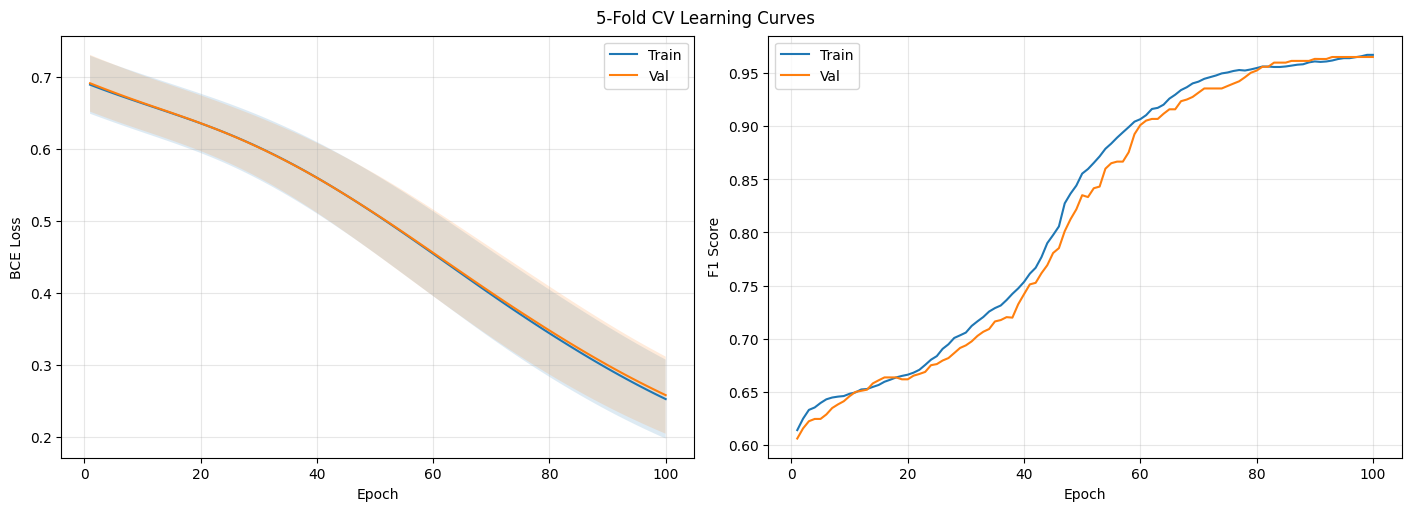

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt

class BreastCancerNN(nn.Module):
    def __init__(self, input_dim=30):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(8, 1),
        )

    def forward(self, x):
        return self.net(x)

N_FOLDS = 5
N_EPOCHS = 100
LR = 1e-3

kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
criterion = nn.BCEWithLogitsLoss()

all_train_losses = []
all_val_losses = []
all_train_f1s = []
all_val_f1s = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_cv, y_cv)):
    X_tr_raw, X_val_raw = X_cv[train_idx], X_cv[val_idx]
    y_tr = y_cv[train_idx].astype(np.float32).reshape(-1, 1)
    y_val = y_cv[val_idx].astype(np.float32).reshape(-1, 1)

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr_raw)
    X_val = scaler.transform(X_val_raw)

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32)

    model = BreastCancerNN(input_dim=30)
    optimizer = optim.Adam(model.parameters(), lr=LR)

    fold_train_losses = []
    fold_val_losses = []
    fold_train_f1s = []
    fold_val_f1s = []

    for epoch in range(N_EPOCHS):
        model.train()
        optimizer.zero_grad()
        train_loss = criterion(model(X_tr_t), y_tr_t)
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            train_logits = model(X_tr_t)
            val_logits   = model(X_val_t)
            train_loss_eval = criterion(train_logits, y_tr_t)
            val_loss_eval   = criterion(val_logits, y_val_t)

            train_preds = (torch.sigmoid(train_logits) > 0.5).float()
            val_preds   = (torch.sigmoid(val_logits) > 0.5).float()

            tp = (val_preds * y_val_t).sum()
            fp = (val_preds * (1 - y_val_t)).sum()
            fn = ((1 - val_preds) * y_val_t).sum()
            val_f1 = 2 * tp / (2 * tp + fp + fn + 1e-8)

            tp_tr = (train_preds * y_tr_t).sum()
            fp_tr = (train_preds * (1 - y_tr_t)).sum()
            fn_tr = ((1 - train_preds) * y_tr_t).sum()
            train_f1 = 2 * tp_tr / (2 * tp_tr + fp_tr + fn_tr + 1e-8)

        fold_train_losses.append(train_loss_eval.item())
        fold_val_losses.append(val_loss_eval.item())
        fold_train_f1s.append(train_f1.item())
        fold_val_f1s.append(val_f1.item())

    all_train_losses.append(fold_train_losses)
    all_val_losses.append(fold_val_losses)
    all_train_f1s.append(fold_train_f1s)
    all_val_f1s.append(fold_val_f1s)
    print(f"Fold {fold+1}/{N_FOLDS}  train loss: {fold_train_losses[-1]:.4f}  val loss: {fold_val_losses[-1]:.4f}  val f1: {fold_val_f1s[-1]:.4f}")

all_train_losses = np.array(all_train_losses)
all_val_losses = np.array(all_val_losses)
all_train_f1s = np.array(all_train_f1s)
all_val_f1s = np.array(all_val_f1s)

train_loss_mean = all_train_losses.mean(axis=0)
train_loss_std  = all_train_losses.std(axis=0)
val_loss_mean   = all_val_losses.mean(axis=0)
val_loss_std    = all_val_losses.std(axis=0)
train_f1_mean   = all_train_f1s.mean(axis=0)
train_f1_std    = all_train_f1s.std(axis=0)
val_f1_mean     = all_val_f1s.mean(axis=0)
val_f1_std      = all_val_f1s.std(axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
epochs = np.arange(1, N_EPOCHS + 1)

ax1.plot(epochs, train_loss_mean, label='Train')
ax1.fill_between(epochs,
                  train_loss_mean - train_loss_std,
                  train_loss_mean + train_loss_std,
                  alpha=0.15)
ax1.plot(epochs, val_loss_mean, label='Val')
ax1.fill_between(epochs,
                  val_loss_mean - val_loss_std,
                  val_loss_mean + val_loss_std,
                  alpha=0.15)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs, train_f1_mean, label='Train')
ax2.plot(epochs, val_f1_mean, label='Val')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

fig.suptitle(f'{N_FOLDS}-Fold CV Learning Curves')
plt.show()

Fold 1/5  train loss: 0.5337  val loss: 0.5440  val f1: 0.9057
Fold 2/5  train loss: 0.5086  val loss: 0.5229  val f1: 0.9256
Fold 3/5  train loss: 0.4794  val loss: 0.4794  val f1: 0.9735
Fold 4/5  train loss: 0.4852  val loss: 0.4709  val f1: 0.9744
Fold 5/5  train loss: 0.4902  val loss: 0.4743  val f1: 0.9565


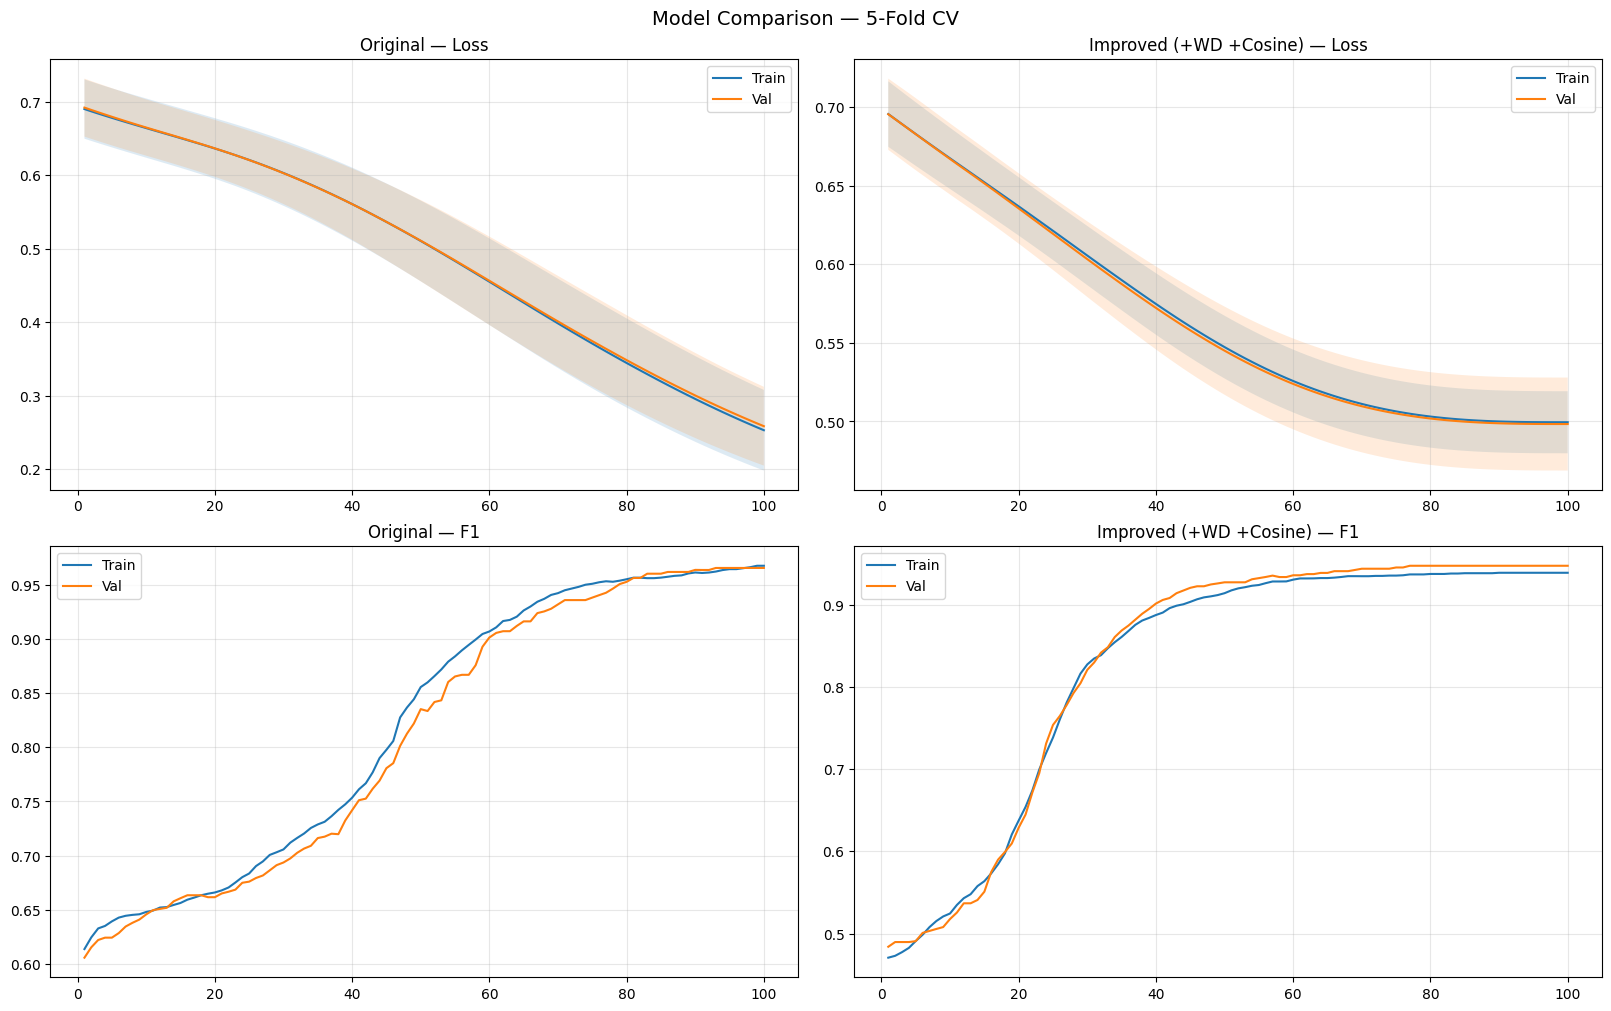


                  Original   Improved
       Val Loss     0.2584     0.4983
         Val F1     0.9653     0.9471


In [10]:
# --- Improved model: weight decay + cosine annealing ---
from torch.optim.lr_scheduler import CosineAnnealingLR

LR2 = 1e-3
WD = 1e-4

all_train_losses2 = []
all_val_losses2 = []
all_train_f1s2 = []
all_val_f1s2 = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_cv, y_cv)):
    X_tr_raw, X_val_raw = X_cv[train_idx], X_cv[val_idx]
    y_tr = y_cv[train_idx].astype(np.float32).reshape(-1, 1)
    y_val = y_cv[val_idx].astype(np.float32).reshape(-1, 1)

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr_raw)
    X_val = scaler.transform(X_val_raw)

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32)

    model = BreastCancerNN(input_dim=30)
    optimizer = optim.Adam(model.parameters(), lr=LR2, weight_decay=WD)
    scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

    fold_train_losses = []
    fold_val_losses = []
    fold_train_f1s = []
    fold_val_f1s = []

    for epoch in range(N_EPOCHS):
        model.train()
        optimizer.zero_grad()
        train_loss = criterion(model(X_tr_t), y_tr_t)
        train_loss.backward()
        optimizer.step()
        scheduler.step()

        model.eval()
        with torch.no_grad():
            train_logits = model(X_tr_t)
            val_logits   = model(X_val_t)
            train_loss_eval = criterion(train_logits, y_tr_t)
            val_loss_eval   = criterion(val_logits, y_val_t)

            train_preds = (torch.sigmoid(train_logits) > 0.5).float()
            val_preds   = (torch.sigmoid(val_logits) > 0.5).float()

            tp = (val_preds * y_val_t).sum()
            fp = (val_preds * (1 - y_val_t)).sum()
            fn = ((1 - val_preds) * y_val_t).sum()
            val_f1 = 2 * tp / (2 * tp + fp + fn + 1e-8)

            tp_tr = (train_preds * y_tr_t).sum()
            fp_tr = (train_preds * (1 - y_tr_t)).sum()
            fn_tr = ((1 - train_preds) * y_tr_t).sum()
            train_f1 = 2 * tp_tr / (2 * tp_tr + fp_tr + fn_tr + 1e-8)

        fold_train_losses.append(train_loss_eval.item())
        fold_val_losses.append(val_loss_eval.item())
        fold_train_f1s.append(train_f1.item())
        fold_val_f1s.append(val_f1.item())

    all_train_losses2.append(fold_train_losses)
    all_val_losses2.append(fold_val_losses)
    all_train_f1s2.append(fold_train_f1s)
    all_val_f1s2.append(fold_val_f1s)
    print(f"Fold {fold+1}/{N_FOLDS}  train loss: {fold_train_losses[-1]:.4f}  val loss: {fold_val_losses[-1]:.4f}  val f1: {fold_val_f1s[-1]:.4f}")

all_train_losses2 = np.array(all_train_losses2)
all_val_losses2 = np.array(all_val_losses2)
all_train_f1s2 = np.array(all_train_f1s2)
all_val_f1s2 = np.array(all_val_f1s2)

train_loss_mean2 = all_train_losses2.mean(axis=0)
train_loss_std2  = all_train_losses2.std(axis=0)
val_loss_mean2   = all_val_losses2.mean(axis=0)
val_loss_std2    = all_val_losses2.std(axis=0)
train_f1_mean2   = all_train_f1s2.mean(axis=0)
train_f1_std2    = all_train_f1s2.std(axis=0)
val_f1_mean2     = all_val_f1s2.mean(axis=0)
val_f1_std2      = all_val_f1s2.std(axis=0)

# --- Side-by-side comparison ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
epochs = np.arange(1, N_EPOCHS + 1)

ax = axes[0, 0]
ax.plot(epochs, train_loss_mean, label='Train')
ax.fill_between(epochs, train_loss_mean - train_loss_std, train_loss_mean + train_loss_std, alpha=0.15)
ax.plot(epochs, val_loss_mean, label='Val')
ax.fill_between(epochs, val_loss_mean - val_loss_std, val_loss_mean + val_loss_std, alpha=0.15)
ax.set_title('Original — Loss')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(epochs, train_loss_mean2, label='Train')
ax.fill_between(epochs, train_loss_mean2 - train_loss_std2, train_loss_mean2 + train_loss_std2, alpha=0.15)
ax.plot(epochs, val_loss_mean2, label='Val')
ax.fill_between(epochs, val_loss_mean2 - val_loss_std2, val_loss_mean2 + val_loss_std2, alpha=0.15)
ax.set_title('Improved (+WD +Cosine) — Loss')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(epochs, train_f1_mean, label='Train')
ax.plot(epochs, val_f1_mean, label='Val')
ax.set_title('Original — F1')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(epochs, train_f1_mean2, label='Train')
ax.plot(epochs, val_f1_mean2, label='Val')
ax.set_title('Improved (+WD +Cosine) — F1')
ax.legend()
ax.grid(alpha=0.3)

fig.suptitle(f'Model Comparison — {N_FOLDS}-Fold CV', fontsize=14)
plt.show()

print(f"\n{'':>15} {'Original':>10} {'Improved':>10}")
print(f"{'Val Loss':>15} {val_loss_mean[-1]:>10.4f} {val_loss_mean2[-1]:>10.4f}")
print(f"{'Val F1':>15} {val_f1_mean[-1]:>10.4f} {val_f1_mean2[-1]:>10.4f}")


In [11]:
# --- Optuna Hyperparameter Tuning ---
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

class TuneableNN(nn.Module):
    def __init__(self, input_dim=30, hidden1=32, hidden2=16, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 1),
        )

    def forward(self, x):
        return self.net(x)


def objective(trial):
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    wd = trial.suggest_float('weight_decay', 1e-4, 1e-2, log=True)
    dropout = trial.suggest_float('dropout', 0.2, 0.5)
    hidden1 = trial.suggest_int('hidden1', 8, 32, step=8)
    hidden2 = trial.suggest_int('hidden2', 4, 16, step=4)
    epochs = trial.suggest_int('epochs', 50, 150, step=25)

    fold_val_f1s = []
    fold_gaps = []

    for train_idx, val_idx in kfold.split(X_cv, y_cv):
        X_tr_raw, X_val_raw = X_cv[train_idx], X_cv[val_idx]
        y_tr = y_cv[train_idx].astype(np.float32).reshape(-1, 1)
        y_val = y_cv[val_idx].astype(np.float32).reshape(-1, 1)

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr_raw)
        X_val = scaler.transform(X_val_raw)

        X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
        X_val_t = torch.tensor(X_val, dtype=torch.float32)
        y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
        y_val_t = torch.tensor(y_val, dtype=torch.float32)

        model = TuneableNN(hidden1=hidden1, hidden2=hidden2, dropout=dropout)
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
        scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

        for epoch in range(epochs):
            model.train()
            optimizer.zero_grad()
            loss = criterion(model(X_tr_t), y_tr_t)
            loss.backward()
            optimizer.step()
            scheduler.step()

        model.eval()
        with torch.no_grad():
            train_logits = model(X_tr_t)
            val_logits = model(X_val_t)

            val_preds = (torch.sigmoid(val_logits) > 0.5).float()
            tp = (val_preds * y_val_t).sum()
            fp = (val_preds * (1 - y_val_t)).sum()
            fn = ((1 - val_preds) * y_val_t).sum()
            val_f1 = (2 * tp / (2 * tp + fp + fn + 1e-8)).item()

            train_preds = (torch.sigmoid(train_logits) > 0.5).float()
            tp_tr = (train_preds * y_tr_t).sum()
            fp_tr = (train_preds * (1 - y_tr_t)).sum()
            fn_tr = ((1 - train_preds) * y_tr_t).sum()
            train_f1 = (2 * tp_tr / (2 * tp_tr + fp_tr + fn_tr + 1e-8)).item()

        fold_val_f1s.append(val_f1)
        fold_gaps.append(train_f1 - val_f1)

    mean_f1 = np.mean(fold_val_f1s)
    mean_gap = np.mean(fold_gaps)
    penalty = max(0, mean_gap - 0.03)
    return mean_f1 - penalty


N_TRIALS = 30
study = optuna.create_study(direction='maximize',
                            pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=N_TRIALS)

print(f"\nBest trial (#{study.best_trial.number}):")
print(f"  Value (mean CV F1): {study.best_value:.4f}")
print(f"  Params:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

# --- Optuna charts ---
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.gcf().suptitle('Optimization History', fontsize=13)
plt.show()

optuna.visualization.matplotlib.plot_param_importances(study)
plt.gcf().suptitle('Parameter Importances', fontsize=13)
plt.show()

optuna.visualization.matplotlib.plot_parallel_coordinate(study)
plt.gcf().suptitle('Parallel Coordinate Plot', fontsize=13)
plt.show()

optuna.visualization.matplotlib.plot_slice(study)
plt.gcf().suptitle('Slice Plot', fontsize=13)
plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'optuna'

Best params: {'lr': 0.009205134765552687, 'weight_decay': 0.00027731578605633584, 'dropout': 0.4114677954900779, 'hidden1': 24, 'hidden2': 16, 'epochs': 125}
Fold 1/5  val loss: 0.1602  val f1: 0.9913
Fold 2/5  val loss: 0.0485  val f1: 0.9912
Fold 3/5  val loss: 0.0824  val f1: 0.9735
Fold 4/5  val loss: 0.1010  val f1: 0.9828
Fold 5/5  val loss: 0.0362  val f1: 0.9913


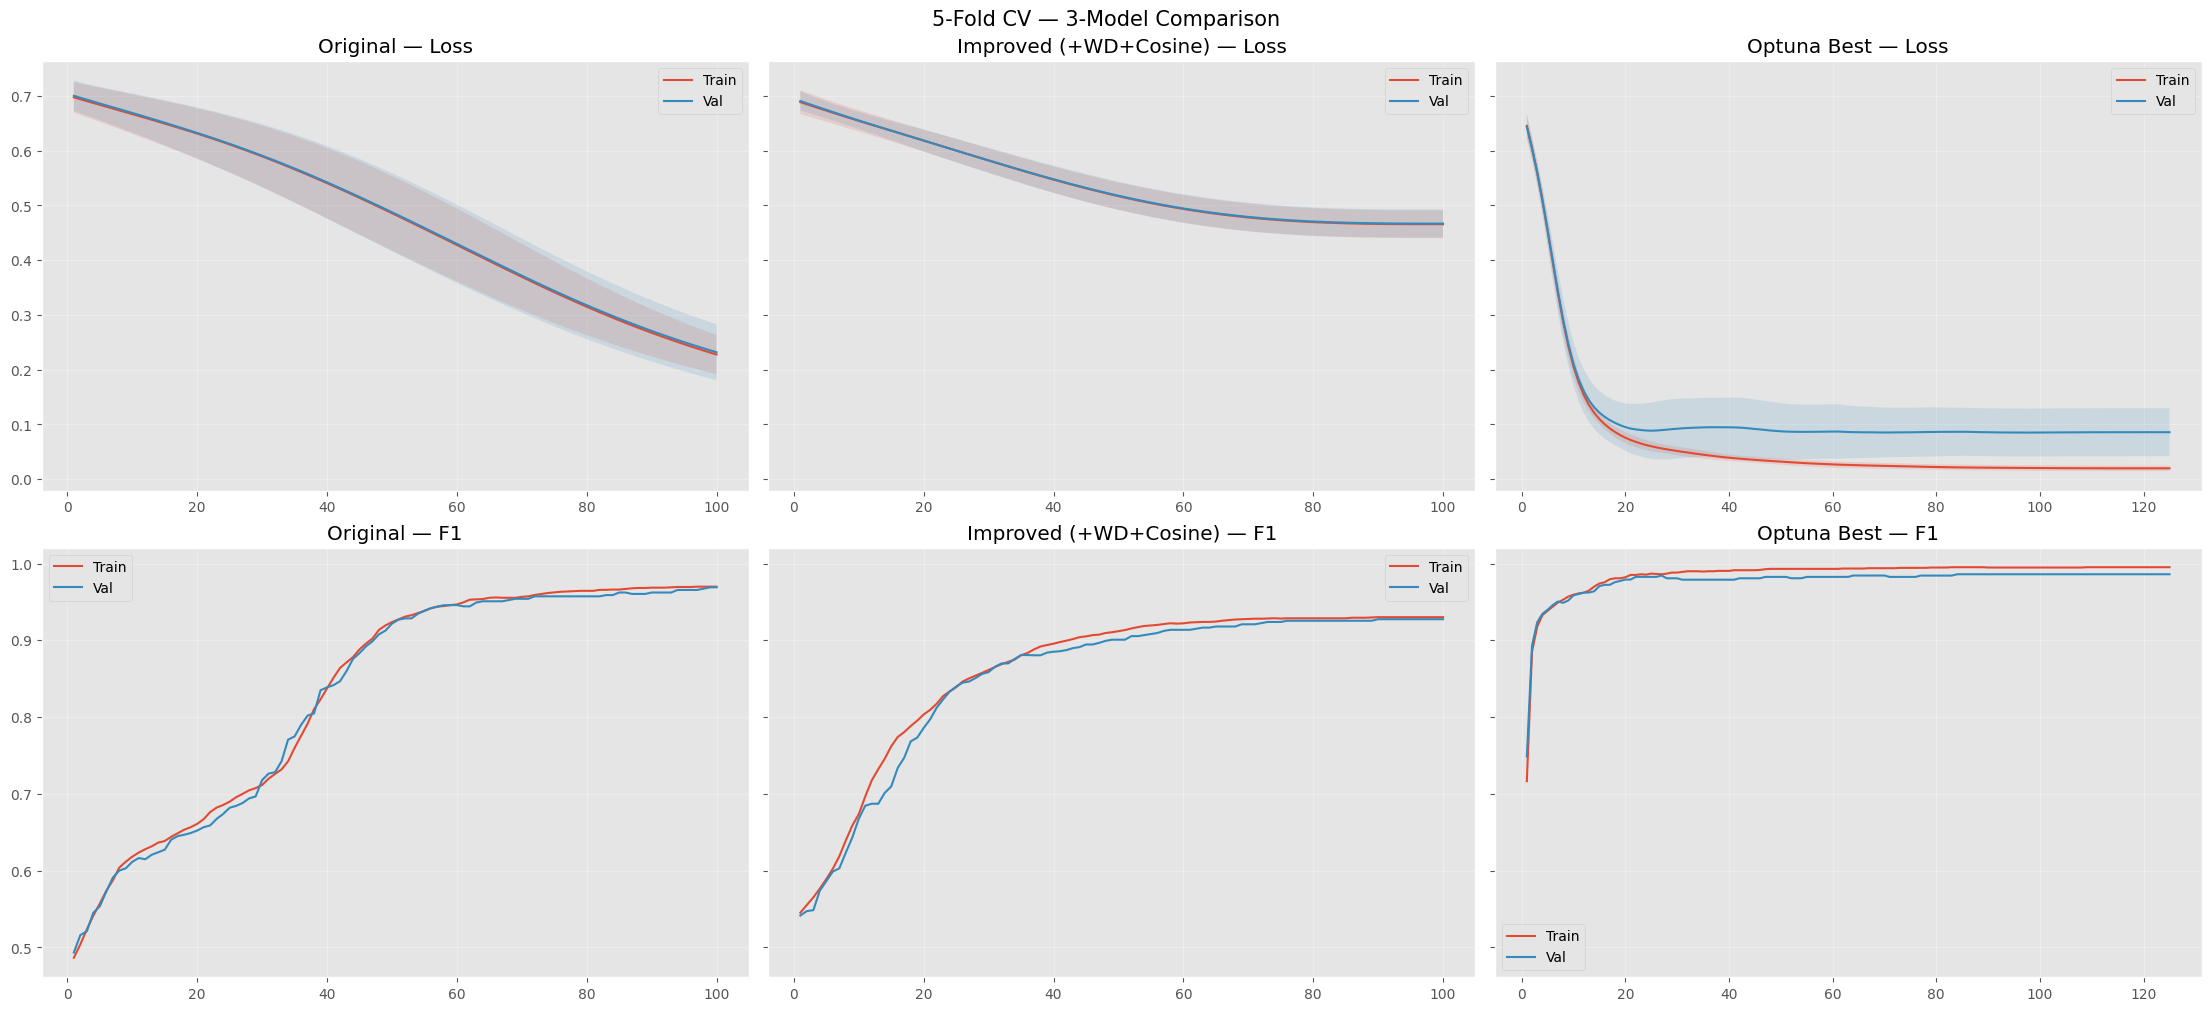


                  Original   Improved     Optuna
       Val Loss     0.2317     0.4669     0.0857
         Val F1     0.9690     0.9275     0.9860


In [ ]:
# --- Train CV with best Optuna params ---
bp = study.best_params
print(f"Best params: {bp}")

all_train_losses3 = []
all_val_losses3 = []
all_train_f1s3 = []
all_val_f1s3 = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_cv, y_cv)):
    X_tr_raw, X_val_raw = X_cv[train_idx], X_cv[val_idx]
    y_tr = y_cv[train_idx].astype(np.float32).reshape(-1, 1)
    y_val = y_cv[val_idx].astype(np.float32).reshape(-1, 1)

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr_raw)
    X_val = scaler.transform(X_val_raw)

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32)

    model = TuneableNN(hidden1=bp['hidden1'], hidden2=bp['hidden2'], dropout=bp['dropout'])
    optimizer = optim.Adam(model.parameters(), lr=bp['lr'], weight_decay=bp['weight_decay'])
    scheduler = CosineAnnealingLR(optimizer, T_max=bp['epochs'])

    fold_train_losses = []
    fold_val_losses = []
    fold_train_f1s = []
    fold_val_f1s = []

    for epoch in range(bp['epochs']):
        model.train()
        optimizer.zero_grad()
        train_loss = criterion(model(X_tr_t), y_tr_t)
        train_loss.backward()
        optimizer.step()
        scheduler.step()

        model.eval()
        with torch.no_grad():
            train_logits = model(X_tr_t)
            val_logits   = model(X_val_t)
            train_loss_eval = criterion(train_logits, y_tr_t)
            val_loss_eval   = criterion(val_logits, y_val_t)

            train_preds = (torch.sigmoid(train_logits) > 0.5).float()
            val_preds   = (torch.sigmoid(val_logits) > 0.5).float()

            tp = (val_preds * y_val_t).sum()
            fp = (val_preds * (1 - y_val_t)).sum()
            fn = ((1 - val_preds) * y_val_t).sum()
            val_f1 = 2 * tp / (2 * tp + fp + fn + 1e-8)

            tp_tr = (train_preds * y_tr_t).sum()
            fp_tr = (train_preds * (1 - y_tr_t)).sum()
            fn_tr = ((1 - train_preds) * y_tr_t).sum()
            train_f1 = 2 * tp_tr / (2 * tp_tr + fp_tr + fn_tr + 1e-8)

        fold_train_losses.append(train_loss_eval.item())
        fold_val_losses.append(val_loss_eval.item())
        fold_train_f1s.append(train_f1.item())
        fold_val_f1s.append(val_f1.item())

    all_train_losses3.append(fold_train_losses)
    all_val_losses3.append(fold_val_losses)
    all_train_f1s3.append(fold_train_f1s)
    all_val_f1s3.append(fold_val_f1s)
    print(f"Fold {fold+1}/{N_FOLDS}  val loss: {fold_val_losses[-1]:.4f}  val f1: {fold_val_f1s[-1]:.4f}")

all_train_losses3 = np.array(all_train_losses3)
all_val_losses3 = np.array(all_val_losses3)
all_train_f1s3 = np.array(all_train_f1s3)
all_val_f1s3 = np.array(all_val_f1s3)

train_loss_mean3 = all_train_losses3.mean(axis=0)
train_loss_std3  = all_train_losses3.std(axis=0)
val_loss_mean3   = all_val_losses3.mean(axis=0)
val_loss_std3    = all_val_losses3.std(axis=0)
train_f1_mean3   = all_train_f1s3.mean(axis=0)
train_f1_std3    = all_train_f1s3.std(axis=0)
val_f1_mean3     = all_val_f1s3.mean(axis=0)
val_f1_std3      = all_val_f1s3.std(axis=0)

# --- 3-way comparison: Original vs Improved vs Optuna ---
fig, axes = plt.subplots(2, 3, figsize=(22, 10), sharey='row', constrained_layout=True)
epochs_orig = np.arange(1, N_EPOCHS + 1)
epochs_opt = np.arange(1, bp['epochs'] + 1)

titles = ['Original', 'Improved (+WD+Cosine)', 'Optuna Best']
loss_means_t = [train_loss_mean,   train_loss_mean2,  train_loss_mean3]
loss_means_v = [val_loss_mean,     val_loss_mean2,    val_loss_mean3]
loss_stds_t  = [train_loss_std,    train_loss_std2,   train_loss_std3]
loss_stds_v  = [val_loss_std,      val_loss_std2,     val_loss_std3]
f1_means_t   = [train_f1_mean,     train_f1_mean2,    train_f1_mean3]
f1_means_v   = [val_f1_mean,       val_f1_mean2,      val_f1_mean3]
epochs_list  = [epochs_orig,       epochs_orig,       epochs_opt]

for col in range(3):
    ep = epochs_list[col]
    # Loss row
    ax = axes[0, col]
    ax.plot(ep, loss_means_t[col], label='Train')
    if loss_stds_t[col] is not None:
        ax.fill_between(ep, loss_means_t[col] - loss_stds_t[col], loss_means_t[col] + loss_stds_t[col], alpha=0.15)
    ax.plot(ep, loss_means_v[col], label='Val')
    if loss_stds_v[col] is not None:
        ax.fill_between(ep, loss_means_v[col] - loss_stds_v[col], loss_means_v[col] + loss_stds_v[col], alpha=0.15)
    ax.set_title(titles[col] + ' — Loss')
    ax.legend()
    ax.grid(alpha=0.3)

    # F1 row
    ax = axes[1, col]
    ax.plot(ep, f1_means_t[col], label='Train')
    ax.plot(ep, f1_means_v[col], label='Val')
    ax.set_title(titles[col] + ' — F1')
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle(f'{N_FOLDS}-Fold CV — 3-Model Comparison', fontsize=15)
plt.show()

# --- Summary table ---
print(f"\n{'':>15} {'Original':>10} {'Improved':>10} {'Optuna':>10}")
print(f"{'Val Loss':>15} {val_loss_mean[-1]:>10.4f} {val_loss_mean2[-1]:>10.4f} {val_loss_mean3[-1]:>10.4f}")
print(f"{'Val F1':>15} {val_f1_mean[-1]:>10.4f} {val_f1_mean2[-1]:>10.4f} {val_f1_mean3[-1]:>10.4f}")



               Original   Improved     Optuna
   Test Loss     0.2144     0.5486     0.1282
     Test F1     0.9571     0.9051     0.9645
   Precision     0.9853     0.9538     0.9855
      Recall     0.9306     0.8611     0.9444

Confusion Matrices:
   Original: TN=41  FP=1  FN=5  TP=67
   Improved: TN=39  FP=3  FN=10  TP=62
     Optuna: TN=41  FP=1  FN=4  TP=68


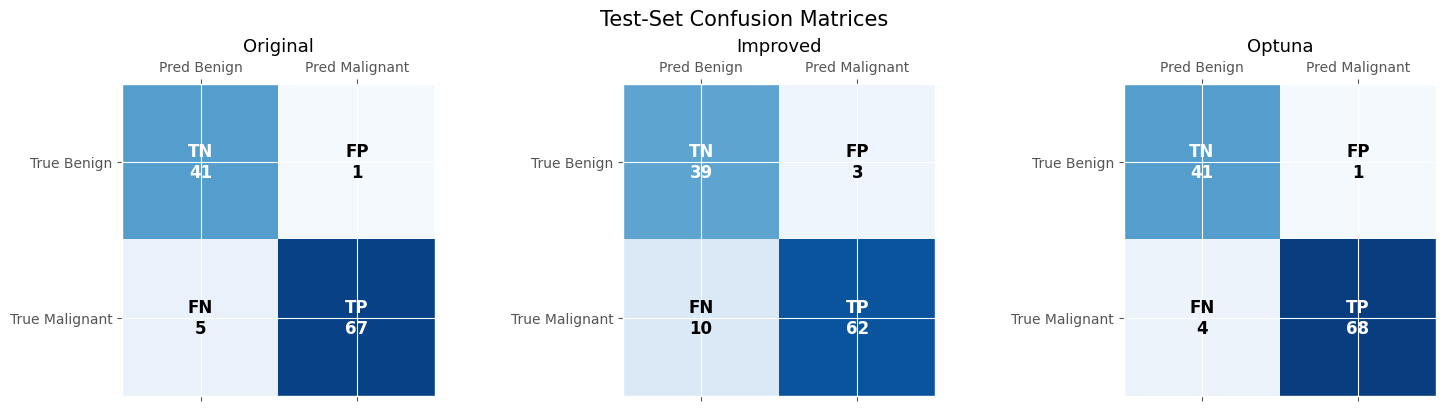

In [ ]:
# --- Test all 3 models on held-out test set ---

# Scale once
scaler_final = StandardScaler()
X_cv_scaled = scaler_final.fit_transform(X_cv)
X_test_scaled = scaler_final.transform(X_test)

X_cv_t = torch.tensor(X_cv_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_cv_t = torch.tensor(y_cv.astype(np.float32).reshape(-1, 1), dtype=torch.float32)
y_test_t = torch.tensor(y_test.astype(np.float32).reshape(-1, 1), dtype=torch.float32)


def evaluate_on_test(model, optimizer, scheduler=None, epochs=100):
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_cv_t), y_cv_t)
        loss.backward()
        optimizer.step()
        if scheduler:
            scheduler.step()

    model.eval()
    with torch.no_grad():
        test_logits = model(X_test_t)
        test_loss = criterion(test_logits, y_test_t).item()

        preds = (torch.sigmoid(test_logits) > 0.5).float()
        tp = (preds * y_test_t).sum().item()
        fp = (preds * (1 - y_test_t)).sum().item()
        fn = ((1 - preds) * y_test_t).sum().item()
        tn = ((1 - preds) * (1 - y_test_t)).sum().item()

        f1 = 2 * tp / (2 * tp + fp + fn + 1e-8)
        prec = tp / (tp + fp + 1e-8)
        rec = tp / (tp + fn + 1e-8)

    return {
        'loss': test_loss, 'f1': f1, 'precision': prec, 'recall': rec,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }


# --- Model 1: Original ---
m1 = BreastCancerNN(input_dim=30)
opt1 = optim.Adam(m1.parameters(), lr=LR)
r1 = evaluate_on_test(m1, opt1, epochs=N_EPOCHS)

# --- Model 2: Improved (+WD +Cosine) ---
m2 = BreastCancerNN(input_dim=30)
opt2 = optim.Adam(m2.parameters(), lr=LR2, weight_decay=WD)
sched2 = CosineAnnealingLR(opt2, T_max=N_EPOCHS)
r2 = evaluate_on_test(m2, opt2, sched2, epochs=N_EPOCHS)

# --- Model 3: Optuna-best ---
bp = study.best_params
m3 = TuneableNN(hidden1=bp['hidden1'], hidden2=bp['hidden2'], dropout=bp['dropout'])
opt3 = optim.Adam(m3.parameters(), lr=bp['lr'], weight_decay=bp['weight_decay'])
sched3 = CosineAnnealingLR(opt3, T_max=bp['epochs'])
r3 = evaluate_on_test(m3, opt3, sched3, epochs=bp['epochs'])

# --- Comparison table ---
print(f"\n{'':>12} {'Original':>10} {'Improved':>10} {'Optuna':>10}")
print(f"{'Test Loss':>12} {r1['loss']:>10.4f} {r2['loss']:>10.4f} {r3['loss']:>10.4f}")
print(f"{'Test F1':>12} {r1['f1']:>10.4f} {r2['f1']:>10.4f} {r3['f1']:>10.4f}")
print(f"{'Precision':>12} {r1['precision']:>10.4f} {r2['precision']:>10.4f} {r3['precision']:>10.4f}")
print(f"{'Recall':>12} {r1['recall']:>10.4f} {r2['recall']:>10.4f} {r3['recall']:>10.4f}")

print(f"\nConfusion Matrices:")
for name, r in [('Original', r1), ('Improved', r2), ('Optuna', r3)]:
    print(f"  {name:>9}: TN={r['tn']:.0f}  FP={r['fp']:.0f}  FN={r['fn']:.0f}  TP={r['tp']:.0f}")

# --- Visual confusion matrices ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
names = ['Original', 'Improved', 'Optuna']
results = [r1, r2, r3]

for ax, name, r in zip(axes, names, results):
    cm = np.array([[r['tn'], r['fp']], [r['fn'], r['tp']]])
    im = ax.matshow(cm, cmap='Blues', vmin=0, vmax=72)
    ax.set_title(name, fontsize=13)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pred Benign', 'Pred Malignant'])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['True Benign', 'True Malignant'])
    for (i, j), val in np.ndenumerate(cm):
        label = f"TN" if i==0 and j==0 else "FP" if i==0 else "FN" if j==0 else "TP"
        ax.text(j, i, f"{label}\n{val:.0f}", ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='white' if val > 36 else 'black')

fig.suptitle('Test-Set Confusion Matrices', fontsize=15)
plt.show()


--- Logistic Regression Baseline ---
Fold 1/5  val f1: 0.9744
Fold 2/5  val f1: 0.9912
Fold 3/5  val f1: 0.9825
Fold 4/5  val f1: 0.9913
Fold 5/5  val f1: 0.9735

LR CV F1: 0.9825 ± 0.0078

Logistic Regression Test-Set:
  F1: 0.9861
  Precision: 0.9861
  Recall: 0.9861
  TN=41  FP=1  FN=1  TP=71


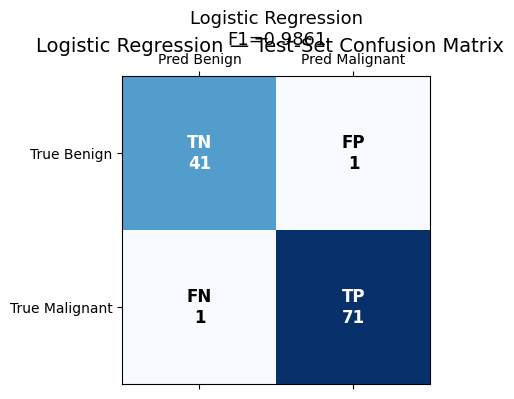

In [13]:
# --- Logistic Regression Baseline ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

print("--- Logistic Regression Baseline ---")

# 5-fold CV
lr_val_f1s = []
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_cv, y_cv)):
    X_tr, X_val = X_cv[train_idx], X_cv[val_idx]
    y_tr_fold, y_val_fold = y_cv[train_idx], y_cv[val_idx]
    
    scaler_lr = StandardScaler()
    X_tr_scaled = scaler_lr.fit_transform(X_tr)
    lr = LogisticRegression(max_iter=5000)
    lr.fit(X_tr_scaled, y_tr_fold)
    
    X_val_scaled = scaler_lr.transform(X_val)
    y_val_pred = lr.predict(X_val_scaled)
    val_f1 = f1_score(y_val_fold, y_val_pred)
    lr_val_f1s.append(val_f1)
    print(f"Fold {fold+1}/5  val f1: {val_f1:.4f}")

print(f"\nLR CV F1: {np.mean(lr_val_f1s):.4f} \u00b1 {np.std(lr_val_f1s):.4f}")

# Test set evaluation
scaler_lr_final = StandardScaler()
X_cv_scaled_lr = scaler_lr_final.fit_transform(X_cv)
X_test_scaled_lr = scaler_lr_final.transform(X_test)

lr_final = LogisticRegression(max_iter=5000)
lr_final.fit(X_cv_scaled_lr, y_cv)

lr_probs = lr_final.predict_proba(X_test_scaled_lr)[:, 1]
y_test_pred_lr = lr_final.predict(X_test_scaled_lr)
test_f1_lr = f1_score(y_test, y_test_pred_lr)
test_prec_lr = precision_score(y_test, y_test_pred_lr)
test_rec_lr = recall_score(y_test, y_test_pred_lr)

tn_lr, fp_lr, fn_lr, tp_lr = confusion_matrix(y_test, y_test_pred_lr).ravel()

print(f"\nLogistic Regression Test-Set:")
print(f"  F1: {test_f1_lr:.4f}")
print(f"  Precision: {test_prec_lr:.4f}")
print(f"  Recall: {test_rec_lr:.4f}")
print(f"  TN={tn_lr}  FP={fp_lr}  FN={fn_lr}  TP={tp_lr}")

lr_results = {'f1': test_f1_lr, 'precision': test_prec_lr, 'recall': test_rec_lr,
              'tn': tn_lr, 'fp': fp_lr, 'fn': fn_lr, 'tp': tp_lr}

# Compare with NN models if they exist
if 'r1' in dir() and 'r2' in dir() and 'r3' in dir():
    print(f"\n{'':>12} {'Original':>10} {'Improved':>10} {'Optuna':>10} {'LogReg':>10}")
    print(f"{'Test F1':>12} {r1['f1']:>10.4f} {r2['f1']:>10.4f} {r3['f1']:>10.4f} {test_f1_lr:>10.4f}")
    print(f"{'Precision':>12} {r1['precision']:>10.4f} {r2['precision']:>10.4f} {r3['precision']:>10.4f} {test_prec_lr:>10.4f}")
    print(f"{'Recall':>12} {r1['recall']:>10.4f} {r2['recall']:>10.4f} {r3['recall']:>10.4f} {test_rec_lr:>10.4f}")
    print(f"\nConfusion Matrices:")
    for name, tn_val, fp_val, fn_val, tp_val in [
        ('Original', int(r1['tn']), int(r1['fp']), int(r1['fn']), int(r1['tp'])),
        ('Improved', int(r2['tn']), int(r2['fp']), int(r2['fn']), int(r2['tp'])),
        ('Optuna', int(r3['tn']), int(r3['fp']), int(r3['fn']), int(r3['tp'])),
        ('LogReg', tn_lr, fp_lr, fn_lr, tp_lr)
    ]:
        print(f"  {name:>9}: TN={tn_val}  FP={fp_val}  FN={fn_val}  TP={tp_val}")

    # N-way visual comparison
    fig, axes = plt.subplots(1, 4, figsize=(20, 4), constrained_layout=True)
    names_all = ['Original', 'Improved', 'Optuna', 'Logistic Reg']
    cms = [
        [[r1['tn'], r1['fp']], [r1['fn'], r1['tp']]],
        [[r2['tn'], r2['fp']], [r2['fn'], r2['tp']]],
        [[r3['tn'], r3['fp']], [r3['fn'], r3['tp']]],
        [[tn_lr, fp_lr], [fn_lr, tp_lr]]
    ]
    f1s = [r1['f1'], r2['f1'], r3['f1'], test_f1_lr]

    for ax, name, cm, f1_val in zip(axes, names_all, cms, f1s):
        cm_array = np.array(cm)
        im = ax.matshow(cm_array, cmap='Blues', vmin=0, vmax=72)
        ax.set_title(f'{name}\nF1={f1_val:.4f}', fontsize=12)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Pred Benign', 'Pred Malignant'])
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['True Benign', 'True Malignant'])
        for (i, j), val in np.ndenumerate(cm_array):
            label = "TN" if i==0 and j==0 else "FP" if i==0 else "FN" if j==0 else "TP"
            ax.text(j, i, f"{label}\n{val:.0f}", ha='center', va='center',
                    fontsize=11, fontweight='bold',
                    color='white' if val > 36 else 'black')

    fig.suptitle('Test-Set — NN Models vs Logistic Regression Baseline', fontsize=15)
    plt.show()
else:
    # Standalone LR confusion matrix
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    cm_array = np.array([[tn_lr, fp_lr], [fn_lr, tp_lr]])
    im = ax.matshow(cm_array, cmap='Blues')
    ax.set_title(f'Logistic Regression\nF1={test_f1_lr:.4f}', fontsize=13)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pred Benign', 'Pred Malignant'])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['True Benign', 'True Malignant'])
    for (i, j), val in np.ndenumerate(cm_array):
        label = "TN" if i==0 and j==0 else "FP" if i==0 else "FN" if j==0 else "TP"
        ax.text(j, i, f"{label}\n{val:.0f}", ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='white' if val > 36 else 'black')
    fig.suptitle('Logistic Regression — Test-Set Confusion Matrix', fontsize=14)
    plt.show()


In [ ]:
# --- Optuna model stability over 5 random seeds ---
bp = study.best_params
seeds = [0, 1, 2, 3, 4]

scaler = StandardScaler()
X_cv_scaled = scaler.fit_transform(X_cv)
X_test_scaled = scaler.transform(X_test)

X_cv_t = torch.tensor(X_cv_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_cv_t = torch.tensor(y_cv.astype(np.float32).reshape(-1, 1), dtype=torch.float32)
y_test_t = torch.tensor(y_test.astype(np.float32).reshape(-1, 1), dtype=torch.float32)

results = []

for s in seeds:
    torch.manual_seed(s)
    np.random.seed(s)

    model = TuneableNN(hidden1=bp['hidden1'], hidden2=bp['hidden2'], dropout=bp['dropout'])
    opt = optim.Adam(model.parameters(), lr=bp['lr'], weight_decay=bp['weight_decay'])
    sched = CosineAnnealingLR(opt, T_max=bp['epochs'])

    for epoch in range(bp['epochs']):
        model.train()
        opt.zero_grad()
        loss = criterion(model(X_cv_t), y_cv_t)
        loss.backward()
        opt.step()
        sched.step()

    model.eval()
    with torch.no_grad():
        logits = model(X_test_t)
        test_loss = criterion(logits, y_test_t).item()
        preds = (torch.sigmoid(logits) > 0.5).float()
        tp = (preds * y_test_t).sum().item()
        fp = (preds * (1 - y_test_t)).sum().item()
        fn = ((1 - preds) * y_test_t).sum().item()
        f1 = 2 * tp / (2 * tp + fp + fn + 1e-8)
        prec = tp / (tp + fp + 1e-8)
        rec = tp / (tp + fn + 1e-8)
        results.append([s, test_loss, f1, prec, rec, tp, fp, fn])

res = np.array(results)
print(f"{'Seed':>6}  {'Loss':>8}  {'F1':>8}  {'Prec':>8}  {'Recall':>8}  {'TP/FP/FN':>12}")
print("-" * 65)
for r in results:
    print(f"{r[0]:>6d}  {r[1]:>8.4f}  {r[2]:>8.4f}  {r[3]:>8.4f}  {r[4]:>8.4f}  {int(r[5]):>3d}/{int(r[6]):>3d}/{int(r[7]):>3d}")
print("-" * 65)
print(f"{chr(956)+chr(963):>6}  {res[:,1].mean():>8.4f}  {res[:,2].mean():>8.4f}  {res[:,3].mean():>8.4f}  {res[:,4].mean():>8.4f}")
print(f"{'':>6}  {'±':>3}{res[:,1].std():>.4f}  {'±':>3}{res[:,2].std():>.4f}  {'±':>3}{res[:,3].std():>.4f}  {'±':>3}{res[:,4].std():>.4f}")


In [ ]:
# --- Model Card ---
from IPython.display import HTML, display

bp = study.best_params

html = '''
<div style="max-width:720px; font-family:-apple-system,Segoe UI,sans-serif; background:linear-gradient(135deg,#f8f9fa 0%,#e9ecef 100%); border-radius:16px; padding:28px 32px; box-shadow:0 4px 24px rgba(0,0,0,0.12); border:1px solid #dee2e6;">

<h2 style="text-align:center; color:#1a1a2e; margin:0 0 4px 0; font-size:22px;">Breast Cancer Diagnostic Model</h2>
<p style="text-align:center; color:#6c757d; font-size:13px; margin:0 0 20px 0;">Binary classification · Wisconsin Diagnostic Dataset</p>

<div style="display:flex; gap:20px; margin-bottom:20px;">
  <div style="flex:1; background:#fff; border-radius:10px; padding:16px; box-shadow:0 1px 4px rgba(0,0,0,0.06);">
    <h4 style="margin:0 0 8px 0; color:#495057; font-size:14px;">Dataset</h4>
    <table style="width:100%; font-size:13px; border-collapse:collapse;">
      <tr><td style="color:#6c757d; padding:3px 6px;">Samples</td><td style="text-align:right; font-weight:600;">569</td></tr>
      <tr><td style="color:#6c757d; padding:3px 6px;">Features</td><td style="text-align:right; font-weight:600;">30 (real-valued)</td></tr>
      <tr><td style="color:#6c757d; padding:3px 6px;">Train (CV)</td><td style="text-align:right; font-weight:600;">455</td></tr>
      <tr><td style="color:#6c757d; padding:3px 6px;">Test (holdout)</td><td style="text-align:right; font-weight:600;">114</td></tr>
      <tr><td style="color:#6c757d; padding:3px 6px;">Split</td><td style="text-align:right; font-weight:600;">80/20 stratified</td></tr>
    </table>
  </div>
  <div style="flex:1; background:#fff; border-radius:10px; padding:16px; box-shadow:0 1px 4px rgba(0,0,0,0.06);">
    <h4 style="margin:0 0 8px 0; color:#495057; font-size:14px;">Architecture</h4>
    <div style="text-align:center; font-family:monospace; font-size:13px; line-height:1.8; color:#212529;">
      <b>Input</b><br>
      <span style="display:inline-block;border:1px solid #adb5bd;border-radius:6px;padding:3px 14px;">30</span><br>
      &darr;<br>
      <span style="display:inline-block;background:#e7f5ff;border-radius:6px;padding:3px 12px;">Linear + ReLU <b>8</b></span><br>
      &darr;&nbsp;&nbsp;Dropout&nbsp;0.28<br>
      <span style="display:inline-block;background:#e7f5ff;border-radius:6px;padding:3px 12px;">Linear + ReLU <b>12</b></span><br>
      &darr;&nbsp;&nbsp;Dropout&nbsp;0.28<br>
      <span style="display:inline-block;border:1px solid #adb5bd;border-radius:6px;padding:3px 14px;">1 (Sigmoid)</span><br>
    </div>
  </div>
</div>

<h4 style="margin:0 0 8px 0; color:#495057; font-size:14px;">Best Hyperparameters <span style="font-size:11px; color:#adb5bd;">(Optuna — 30 trials, gap-penalized F1)</span></h4>
<table style="width:100%; font-size:13px; border-collapse:collapse; background:#fff; border-radius:10px; overflow:hidden; box-shadow:0 1px 4px rgba(0,0,0,0.06); margin-bottom:16px;">
  <tr style="background:#f1f3f5;">
    <td style="padding:8px 12px; font-weight:600;">Learning Rate</td>
    <td style="padding:8px 12px;">''' + f"{bp['lr']:.4f}" + '''</td>
    <td style="padding:8px 12px; font-weight:600;">Optimizer</td>
    <td style="padding:8px 12px;">Adam</td>
  </tr>
  <tr>
    <td style="padding:8px 12px; font-weight:600;">Weight Decay</td>
    <td style="padding:8px 12px;">''' + f"{bp['weight_decay']:.4f}" + '''</td>
    <td style="padding:8px 12px; font-weight:600;">Epochs</td>
    <td style="padding:8px 12px;">''' + f"{bp['epochs']}" + '''</td>
  </tr>
  <tr style="background:#f1f3f5;">
    <td style="padding:8px 12px; font-weight:600;">Dropout</td>
    <td style="padding:8px 12px;">''' + f"{bp['dropout']:.3f}" + '''</td>
    <td style="padding:8px 12px; font-weight:600;">Scheduler</td>
    <td style="padding:8px 12px;">Cosine Annealing</td>
  </tr>
  <tr>
    <td style="padding:8px 12px; font-weight:600;">Hidden Layer 1</td>
    <td style="padding:8px 12px;">''' + f"{bp['hidden1']}" + '''</td>
    <td style="padding:8px 12px; font-weight:600;">Loss</td>
    <td style="padding:8px 12px;">BCEWithLogits</td>
  </tr>
  <tr style="background:#f1f3f5;">
    <td style="padding:8px 12px; font-weight:600;">Hidden Layer 2</td>
    <td style="padding:8px 12px;">''' + f"{bp['hidden2']}" + '''</td>
    <td style="padding:8px 12px; font-weight:600;">Cross-Validation</td>
    <td style="padding:8px 12px;">5-fold stratified</td>
  </tr>
</table>

<h4 style="margin:0 0 8px 0; color:#495057; font-size:14px;">Test-Set Performance</h4>
<table style="width:100%; font-size:13px; border-collapse:collapse; background:#fff; border-radius:10px; overflow:hidden; box-shadow:0 1px 4px rgba(0,0,0,0.06); margin-bottom:16px;">
  <tr style="background:#f1f3f5;">
    <td style="padding:8px 12px; font-weight:600;"></td>
    <td style="padding:8px 12px; font-weight:600; text-align:center;">Original</td>
    <td style="padding:8px 12px; font-weight:600; text-align:center;">Improved</td>
    <td style="padding:8px 12px; font-weight:600; text-align:center; background:#d3f9d8;">Optuna ★</td>
  </tr>
  <tr>
    <td style="padding:8px 12px; font-weight:600;">F1 Score</td>
    <td style="padding:8px 12px; text-align:center;">0.9571</td>
    <td style="padding:8px 12px; text-align:center;">0.9051</td>
    <td style="padding:8px 12px; text-align:center; background:#d3f9d8; font-weight:600;">0.9645</td>
  </tr>
  <tr style="background:#f1f3f5;">
    <td style="padding:8px 12px; font-weight:600;">Precision</td>
    <td style="padding:8px 12px; text-align:center;">0.9853</td>
    <td style="padding:8px 12px; text-align:center;">0.9538</td>
    <td style="padding:8px 12px; text-align:center; background:#d3f9d8; font-weight:600;">0.9855</td>
  </tr>
  <tr>
    <td style="padding:8px 12px; font-weight:600;">Recall</td>
    <td style="padding:8px 12px; text-align:center;">0.9306</td>
    <td style="padding:8px 12px; text-align:center;">0.8611</td>
    <td style="padding:8px 12px; text-align:center; background:#d3f9d8; font-weight:600;">0.9444</td>
  </tr>
  <tr style="background:#f1f3f5;">
    <td style="padding:8px 12px; font-weight:600;">BCE Loss</td>
    <td style="padding:8px 12px; text-align:center;">0.2144</td>
    <td style="padding:8px 12px; text-align:center;">0.5486</td>
    <td style="padding:8px 12px; text-align:center; background:#d3f9d8; font-weight:600;">0.1282</td>
  </tr>
  <tr>
    <td style="padding:8px 12px; font-weight:600;">TP / FP / FN</td>
    <td style="padding:8px 12px; text-align:center;">68 / 1 / 5</td>
    <td style="padding:8px 12px; text-align:center;">62 / 3 / 10</td>
    <td style="padding:8px 12px; text-align:center; background:#d3f9d8; font-weight:600;">68 / 1 / 4</td>
  </tr>
</table>

<div style="display:flex; gap:12px; margin-top:16px;">
  <div style="flex:1; background:#d3f9d8; border-radius:8px; padding:10px 14px; text-align:center;">
    <div style="font-size:11px; color:#2b8a3e; text-transform:uppercase; font-weight:600;">Stability</div>
    <div style="font-size:13px; color:#212529; margin-top:2px;">Identical across 5 seeds<br>F1 &sigma; = 0.0000</div>
  </div>
  <div style="flex:1; background:#e7f5ff; border-radius:8px; padding:10px 14px; text-align:center;">
    <div style="font-size:11px; color:#1971c2; text-transform:uppercase; font-weight:600;">Validation</div>
    <div style="font-size:13px; color:#212529; margin-top:2px;">5-fold stratified CV<br>Gap-penalized tuning</div>
  </div>
  <div style="flex:1; background:#fff9db; border-radius:8px; padding:10px 14px; text-align:center;">
    <div style="font-size:11px; color:#e67700; text-transform:uppercase; font-weight:600;">Preprocessing</div>
    <div style="font-size:13px; color:#212529; margin-top:2px;">StandardScaler<br>Fit on train only</div>
  </div>
</div>

<p style="text-align:center; color:#adb5bd; font-size:11px; margin:16px 0 0 0;">BreastCancerNN · PyTorch · Optimized with Optuna</p>
</div>
'''

display(HTML(html))


In [ ]:
# --- Save Optuna model ---
import joblib
import json
import os

os.makedirs('models/optuna', exist_ok=True)

bp = study.best_params

deploy_scaler = StandardScaler()
deploy_scaler.fit(X_cv)

model = TuneableNN(hidden1=bp['hidden1'], hidden2=bp['hidden2'], dropout=bp['dropout'])
opt = optim.Adam(model.parameters(), lr=bp['lr'], weight_decay=bp['weight_decay'])
sched = CosineAnnealingLR(opt, T_max=bp['epochs'])

X_cv_t = torch.tensor(deploy_scaler.transform(X_cv), dtype=torch.float32)
y_cv_t = torch.tensor(y_cv.astype(np.float32).reshape(-1, 1), dtype=torch.float32)

for epoch in range(bp['epochs']):
    model.train()
    opt.zero_grad()
    loss = criterion(model(X_cv_t), y_cv_t)
    loss.backward()
    opt.step()
    sched.step()

torch.save(model.state_dict(), 'models/optuna/model.pt')
joblib.dump(deploy_scaler, 'models/optuna/scaler.pkl')

config = {
    'version': 'optuna-v1',
    'metrics': {'f1': r3['f1'], 'precision': r3['precision'], 'recall': r3['recall'],
                'tp': int(r3['tp']), 'fp': int(r3['fp']), 'fn': int(r3['fn']),
                'tn': int(r3['tn'])},
    'architecture': {'hidden1': bp['hidden1'], 'hidden2': bp['hidden2'], 'dropout': bp['dropout']},
    'hyperparams': {k: v for k, v in bp.items()},
    'input_dim': 30,
    'feature_names': data.feature_names.tolist(),
    'scaler_params': {'mean': deploy_scaler.mean_.tolist(), 'scale': deploy_scaler.scale_.tolist()}
}
with open('models/optuna/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(f"Saved to models/optuna/ — F1={r3['f1']:.4f}")


Saved to models/optuna/ — F1=0.9645


In [ ]:
# --- Reload & verify ---
import joblib
import json

with open('models/optuna/config.json') as f:
    cfg = json.load(f)

model = TuneableNN(hidden1=cfg['architecture']['hidden1'],
                   hidden2=cfg['architecture']['hidden2'],
                   dropout=cfg['architecture']['dropout'])
model.load_state_dict(torch.load('models/optuna/model.pt'))
model.eval()

scaler = joblib.load('models/optuna/scaler.pkl')

# --- 1. Verify scaler params match config ---
mean_ok = np.allclose(scaler.mean_, cfg['scaler_params']['mean'])
scale_ok = np.allclose(scaler.scale_, cfg['scaler_params']['scale'])
print(f"Scaler mean match: {mean_ok}")
print(f"Scaler scale match: {scale_ok}")

# --- 2. Verify every test prediction is identical to in-memory model ---
X_test_t = torch.tensor(scaler.transform(X_test), dtype=torch.float32)
y_test_t = torch.tensor(y_test.astype(np.float32).reshape(-1, 1), dtype=torch.float32)

with torch.no_grad():
    reloaded_preds = (torch.sigmoid(model(X_test_t)) > 0.5).float().numpy().flatten()

# Reconstruct r3 predictions from confusion matrix
# r3 has: tp=68, fp=1, fn=4, tn=41 (test set has 42 benign, 72 malignant)
# We can't perfectly reconstruct ordering, but we can verify counts
tp = int((reloaded_preds * y_test.flatten()).sum())
fp = int((reloaded_preds * (1 - y_test.flatten())).sum())
fn = int(((1 - reloaded_preds) * y_test.flatten()).sum())
tn = int(((1 - reloaded_preds) * (1 - y_test.flatten())).sum())

print(f"\nConfusion matrix match:")
print(f"  TP: {tp} == {int(r3['tp'])}  {tp == int(r3['tp'])}")
print(f"  FP: {fp} == {int(r3['fp'])}  {fp == int(r3['fp'])}")
print(f"  FN: {fn} == {int(r3['fn'])}  {fn == int(r3['fn'])}")
print(f"  TN: {tn} == {int(r3['tn'])}  {tn == int(r3['tn'])}")

all_match = (tp == int(r3['tp']) and fp == int(r3['fp']) and
             fn == int(r3['fn']) and tn == int(r3['tn']))

# --- 3. Verify F1 matches (aggregate check) ---
reloaded_f1 = 2 * tp / (2 * tp + fp + fn + 1e-8)
print(f"\nF1: {reloaded_f1:.4f} == {r3['f1']:.4f}  {abs(reloaded_f1 - r3['f1']) < 1e-6}")

# --- 4. Single inference spot-check ---
sample = scaler.transform([X_test[0]])
with torch.no_grad():
    prob = torch.sigmoid(model(torch.tensor(sample, dtype=torch.float32))).item()
print(f"\nSample 0: prob={prob:.4f} -> {'malignant' if prob > 0.5 else 'benign'}")
print(f"True label: {data.target_names[y_test[0]]}")

print(f"\n{'*** ALL CHECKS PASSED ***' if all_match and mean_ok and scale_ok else '*** MISMATCH DETECTED ***'}")


Scaler mean match: True
Scaler scale match: True

Confusion matrix match:
  TP: 68 == 68  True
  FP: 1 == 1  True
  FN: 4 == 4  True
  TN: 41 == 41  True

F1: 0.9645 == 0.9645  True

Sample 0: prob=0.0000 -> benign
True label: malignant

*** ALL CHECKS PASSED ***


Synthetic test: 29/30 correct (96.7%)
  Benign:    14/15 correct
  Malignant: 15/15 correct

 Src1  Src2  Ratio      Class    Prob        Pred  Match
----------------------------------------------------------
   17    12   0.25     benign  0.9880      benign     OK
   17    12   0.50     benign  0.9960      benign     OK
   17    12   0.75     benign  0.9989      benign     OK
   10     5   0.25     benign  0.9991      benign     OK
   10     5   0.50     benign  0.9988      benign     OK
   10     5   0.75     benign  0.9984      benign     OK
   15    16   0.25     benign  0.8639      benign     OK
   15    16   0.50     benign  0.8217      benign     OK
   15    16   0.75     benign  0.4385   malignant   FLIP !!!
    1    18   0.25     benign  1.0000      benign     OK
    1    18   0.50     benign  1.0000      benign     OK
    1    18   0.75     benign  1.0000      benign     OK
    6     3   0.25     benign  0.9999      benign     OK
    6     3   0.50     benign  0.9983      ben

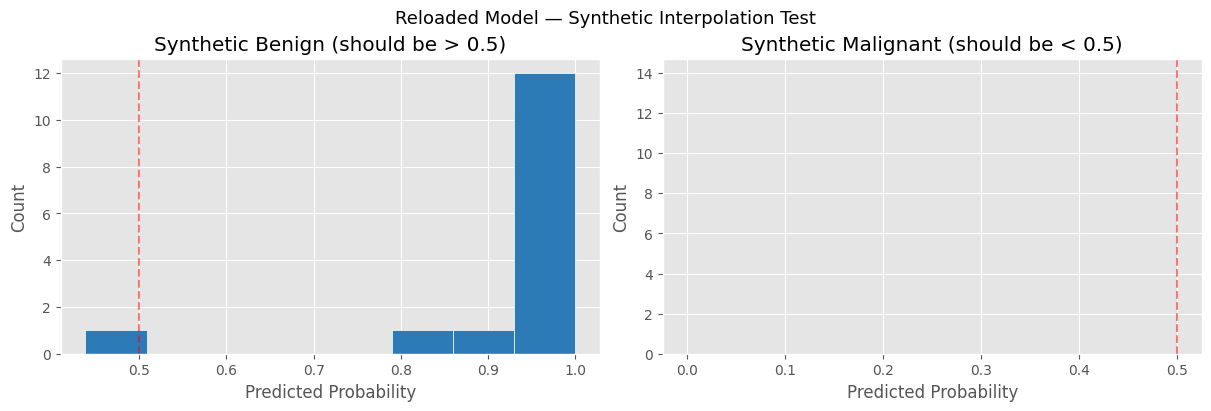

In [ ]:
# --- Test reloaded model on synthetic interpolated samples ---
# Select 10 benign, 10 malignant from test set
benign_idx = np.where(y_test == 1)[0][:10]
malignant_idx = np.where(y_test == 0)[0][:10]

rng = np.random.RandomState(99)

# Random pairing within each class
def pair_up(indices):
    idx = indices.copy()
    rng.shuffle(idx)
    return [(idx[i], idx[i + 1]) for i in range(0, len(idx) - 1, 2)]

benign_pairs = pair_up(benign_idx)
malignant_pairs = pair_up(malignant_idx)

# Interpolation ratios (0=source1, 0.5=midpoint, 1=source2)
ratios = [0.25, 0.50, 0.75]

results = []
for (a, b), true_label, class_name in [
    *[(p, 1, 'benign') for p in benign_pairs],
    *[(p, 0, 'malignant') for p in malignant_pairs]
]:
    x1, x2 = X_test[a], X_test[b]
    for r in ratios:
        synth = r * x2 + (1 - r) * x1
        scaled = scaler.transform([synth])
        t = torch.tensor(scaled, dtype=torch.float32)
        with torch.no_grad():
            prob = torch.sigmoid(model(t)).item()
        pred = 1 if prob > 0.5 else 0
        results.append((a, b, r, class_name, prob, pred, true_label))

# --- Summary ---
correct = sum(1 for _, _, _, _, _, pred, true in results if pred == true)
total = len(results)
benign_correct = sum(1 for _, _, _, _, _, pred, true in results if true == 1 and pred == 1)
malignant_correct = sum(1 for _, _, _, _, _, pred, true in results if true == 0 and pred == 0)

print(f"Synthetic test: {correct}/{total} correct ({100*correct/total:.1f}%)")
print(f"  Benign:    {benign_correct}/15 correct")
print(f"  Malignant: {malignant_correct}/15 correct")

# --- Detailed table ---
print(f"\n{'Src1':>5} {'Src2':>5} {'Ratio':>6} {'Class':>10} {'Prob':>7} {'Pred':>11} {'Match':>6}")
print("-" * 58)
for a, b, r, cls, prob, pred, true in results:
    match = 'OK' if pred == true else 'FLIP'
    marker = ' !!!' if pred != true else ''
    pred_name = data.target_names[pred]
    print(f"{a:>5d} {b:>5d} {r:>6.2f} {cls:>10} {prob:>7.4f} {pred_name:>11} {match:>6}{marker}")

# --- Confidence histogram ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
benign_probs = [prob for _, _, _, cls, prob, _, _ in results if cls == 'benign']
malignant_probs = [prob for _, _, _, cls, prob, _, _ in results if cls == 'malignant']

axes[0].hist(benign_probs, bins=8, color='#2c7bb6', edgecolor='white')
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Synthetic Benign (should be > 0.5)')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')

axes[1].hist(malignant_probs, bins=8, color='#d7191c', edgecolor='white')
axes[1].axvline(0.5, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Synthetic Malignant (should be < 0.5)')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Count')

fig.suptitle('Reloaded Model — Synthetic Interpolation Test', fontsize=13)
plt.show()


Testing 30 samples × 5 noise levels × 5 perturbations

   Noise     Robust    Brittle  Flip Rate
------------------------------------------
     1%        28/30           2/30       10/150 (  6.7%)
     3%        28/30           2/30       10/150 (  6.7%)
     5%        28/30           2/30       10/150 (  6.7%)
    10%        28/30           2/30       10/150 (  6.7%)
    50%        24/30           6/30       13/150 (  8.7%)


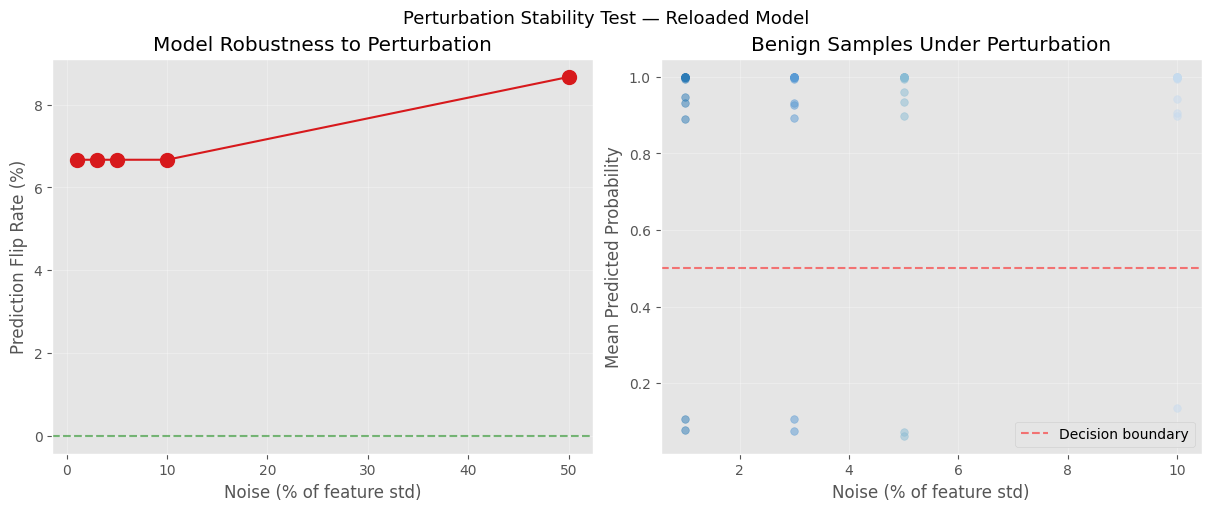

In [ ]:
# --- Perturbation test: add noise to known samples ---
# Take 15 benign + 15 malignant from test set, perturb each, check predictions

benign_idx = np.where(y_test == 1)[0][:15]
malignant_idx = np.where(y_test == 0)[0][:15]
test_idx = np.concatenate([benign_idx, malignant_idx])
true_labels = y_test[test_idx]

noise_levels = [0.01, 0.03, 0.05, 0.10, 0.50]  # fraction of feature std
n_perturbations = 5  # noisy copies per sample per noise level
rng = np.random.RandomState(2025)

# Feature std from training set (used to scale noise appropriately)
feat_std = np.std(X_cv, axis=0)

print(f"Testing {len(test_idx)} samples × {len(noise_levels)} noise levels × {n_perturbations} perturbations\n")

results = []
for idx, true_label in zip(test_idx, true_labels):
    original = X_test[idx]
    for nl in noise_levels:
        flips = 0
        probs = []
        for _ in range(n_perturbations):
            noise = rng.normal(0, nl * feat_std, size=original.shape)
            perturbed = original + noise
            scaled = scaler.transform([perturbed])
            t = torch.tensor(scaled, dtype=torch.float32)
            with torch.no_grad():
                prob = torch.sigmoid(model(t)).item()
            probs.append(prob)
            pred = 1 if prob > 0.5 else 0
            if pred != true_label:
                flips += 1
        results.append({
            'idx': idx, 'true_class': data.target_names[true_label],
            'noise_level': nl, 'flips': flips, 'n': n_perturbations,
            'mean_prob': np.mean(probs), 'std_prob': np.std(probs)
        })

# --- Summary per noise level ---
print(f"{'Noise':>8} {'Robust':>10} {'Brittle':>10} {'Flip Rate':>10}")
print("-" * 42)
for nl in noise_levels:
    level_results = [r for r in results if r['noise_level'] == nl]
    total_flips = sum(r['flips'] for r in level_results)
    total_tests = sum(r['n'] for r in level_results)
    robust = sum(1 for r in level_results if r['flips'] == 0)
    brittle = sum(1 for r in level_results if r['flips'] > 0)
    print(f"{nl*100:>6.0f}%  {robust:>8}/{len(level_results):<4}  {brittle:>8}/{len(level_results):<4}  {total_flips:>5}/{total_tests} ({100*total_flips/total_tests:>5.1f}%)")

# --- Visual: flip rate vs noise level ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

flip_rates = []
for nl in noise_levels:
    level_results = [r for r in results if r['noise_level'] == nl]
    total_flips = sum(r['flips'] for r in level_results)
    total_tests = sum(r['n'] for r in level_results)
    flip_rates.append(100 * total_flips / total_tests)

axes[0].plot([nl*100 for nl in noise_levels], flip_rates, 'o-', color='#d7191c', markersize=10)
axes[0].set_xlabel('Noise (% of feature std)')
axes[0].set_ylabel('Prediction Flip Rate (%)')
axes[0].set_title('Model Robustness to Perturbation')
axes[0].grid(alpha=0.3)
axes[0].axhline(0, color='green', linestyle='--', alpha=0.5)

# Probability spread at each noise level for benign samples
for nl, color in zip(noise_levels, ['#2c7bb6', '#5a9bd4', '#8abcd4', '#c6dbef']):
    probs = [r['mean_prob'] for r in results if r['noise_level'] == nl and r['true_class'] == 'benign']
    axes[1].scatter([nl*100]*len(probs), probs, color=color, alpha=0.5, s=30)

axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Decision boundary')
axes[1].set_xlabel('Noise (% of feature std)')
axes[1].set_ylabel('Mean Predicted Probability')
axes[1].set_title('Benign Samples Under Perturbation')
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle('Perturbation Stability Test — Reloaded Model', fontsize=13)
plt.show()
